# Simulating the BB84 Protocol Under Noise: How Does Quantum Error Impact Security? 

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

### Step 1: Alice selects a random bit-string and a random basis in which to polarize each photon

In [116]:
num_bits = 10
bit_options = [0,1]
basis_options = ['X', 'Z']
def encoding_process(num_bits, basis_options):
    #Alice's random bit-string
    alice_bit_string = []
    for _ in range(num_bits):
        bit = random.choice(bit_options)
        alice_bit_string.append(bit)
    print("Alice's random bit-string:", *alice_bit_string)
    
    #Alice's random basis
    alice_basis_string = []
    for _ in range(num_bits):
        basis = random.choice(basis_options)
        alice_basis_string.append(basis)
    print("Alice's random basis choices:", *alice_basis_string)
    
    #Alice's encoded (polarized) bit-string
    print("\n                   Encoding Procedure:")
    print("                                 bit=0, basis=X -> \u2191\n") #polarized up
    print("                                 bit=1, basis=X -> \u2193\n") #polarized down
    print("                                 bit=0, basis=Z -> \u2192\n") #polarized right
    print("                                 bit=1, basis=Z -> \u2190\n") #polarized left
    
    polarized_string = []
    for bit, basis in zip(alice_bit_string, alice_basis_string):
        if (bit == 0 and basis == 'X'):
            polarized_string.append("\u2191")
        elif (bit == 1 and basis == 'X'):
            polarized_string.append("\u2193")
        elif (bit == 0 and basis == 'Z'):
            polarized_string.append("\u2192")
        elif (bit == 1 and basis == 'Z'):
            polarized_string.append("\u2190")
    print("                   Alice's polarized (encoded) bit-string:", *polarized_string, "\n")
    sent_bit_string = alice_bit_string #bit-string sent to either Bob (no eavesdropper present) or Eve (eavesdropper present)
    return alice_basis_string, alice_bit_string, sent_bit_string
alice_basis_string, alice_bit_string, sent_bit_string = encoding_process(num_bits, basis_options)

Alice's random bit-string: 0 1 1 1 0 0 1 1 1 1
Alice's random basis choices: X Z X Z X X Z Z X X

                   Encoding Procedure:
                                 bit=0, basis=X -> ↑

                                 bit=1, basis=X -> ↓

                                 bit=0, basis=Z -> →

                                 bit=1, basis=Z -> ←

                   Alice's polarized (encoded) bit-string: ↑ ← ↓ ← ↑ ↑ ← ← ↓ ↓ 



### Step 2 (Optional): Presence of an Eavesdropper

In [117]:
def eavesdropping(alice_basis_string, alice_bit_string, basis_options, num_bits):
    #Eve's random basis
    eve_basis_string = []
    for _ in range(num_bits):
        basis = random.choice(basis_options)
        eve_basis_string.append(basis)
    print("Eve's random basis choices:", *eve_basis_string)
    
    #Eve's decoded bit_string
    eve_bit_string = []
    for alice_basis, eve_basis, alice_bit in zip(alice_basis_string, eve_basis_string, alice_bit_string):
        if (alice_basis == eve_basis):
            eve_bit_string.append(alice_bit)
        else:
            eve_bit_string.append(random.choice(bit_options))
    print("Eve's decoded bit-string:", *eve_bit_string)
    sent_bit_string = eve_bit_string #If eavesdropper is present, Bob will receive this bit-string instead of Alice's
    return eve_basis_string, eve_bit_string, sent_bit_string
eve_basis_string, eve_bit_string, sent_bit_string = eavesdropping(alice_basis_string, alice_bit_string, basis_options, num_bits)

Eve's random basis choices: Z X X Z Z X Z X X Z
Eve's decoded bit-string: 0 0 1 1 0 0 1 0 1 1


### Step 3 (Optional): Implementing Quantum Error

**Bit-Flip Error: Flips bit with probability p from 0->1 or 1->0**

In [118]:
def bit_flip_error(sent_bit_string, p_bit_flip):
    bit_flipped_string = []
    for bit in sent_bit_string:
        if random.random() < p_bit_flip:
            bit = 1-bit
        bit_flipped_string.append(bit)
    return bit_flipped_string
sent_bit_string = bit_flip_error(sent_bit_string, p_bit_flip = 0.10)

**Phase-Flip Error: Flips bit with probability p only if it was prepared in X-basis**

In [119]:
def phase_flip_error(alice_basis_string, sent_bit_string, p_phase_flip):
    sent_bit_basis_string = alice_basis_string
    phase_flipped_string = []
    for bit, basis in zip(sent_bit_string, sent_bit_basis_string):
        if (basis == 'X'):
            if random.random() < p_phase_flip:
                bit = np.abs(bit-1)
        phase_flipped_string.append(bit)
    return phase_flipped_string
sent_bit_string = phase_flip_error(alice_basis_string, sent_bit_string, p_phase_flip = 0.10)

**Depolarization Error: Bit essentially loses its quantum information and is randomized**

In [120]:
def depolarizing_error(alice_basis_string, sent_bit_string, p_depolarization):
    polarized_string = []
    for bit, basis in zip(sent_bit_string, alice_basis_string):
        if random.random() < p_depolarization:
            error_type = random.choice(['X', 'Y', 'Z'])
            if error_type == 'X':
                bit = 1 - bit
            elif error_type == 'Z':
                if basis == 'X':
                    bit = 1 - bit
            elif error_type == 'Y':
                bit = 1 - bit
                if basis == 'X':
                    bit = 1 - bit
        polarized_string.append(bit)
    return polarized_string
sent_bit_string = depolarizing_error(alice_basis_string, sent_bit_string, p_depolarization = 0.10)

### Step 4: Bob measures each photon using a randomly chosen basis

In [121]:
def decoding_process(sent_bit_string, alice_basis_string, num_bits, basis_options):
    #Bob's random basis
    bit_options = [0, 1]
    bob_basis_string = []
    for _ in range(num_bits):
        basis = random.choice(basis_options)
        bob_basis_string.append(basis)
    print("Bob's random basis choices:", *bob_basis_string)
    
    #Bob's decoded bit_string
    decoded_string = []
    for alice_basis, bob_basis, received_bit in zip(alice_basis_string, bob_basis_string, sent_bit_string):
        if (alice_basis == bob_basis):
            decoded_string.append(received_bit)
        else:
            decoded_string.append(random.choice(bit_options))
    print("Bob's decoded bit-string:", *decoded_string, "\n")
    return decoded_string, bob_basis_string
decoded_string, bob_basis_string = decoding_process(sent_bit_string, alice_basis_string, num_bits, basis_options)

Bob's random basis choices: Z X Z Z X Z X X X Z
Bob's decoded bit-string: 1 1 0 1 0 0 1 1 0 1 



**Visualization**

In [122]:
#Visualizing all Bases & Bit-Strings
print("VISUALIZATION:")
eavesdropper_presence = True
if (eavesdropper_presence == True):
    df = pd.DataFrame({
        "Label": [
            "Alice Basis:",
            "Alice Bit-String:",
            "Eve Basis-String:",
            "Eve Bit-String:",
            "Bob Basis-String:",
            "Bob Bit-String:"
        ],
        "Value": [
            alice_basis_string,
            alice_bit_string,
            eve_basis_string,
            eve_bit_string,
            bob_basis_string,
            decoded_string
        ]
    })
else:
    df = pd.DataFrame({
        "Label": [
            "Alice Basis:",
            "Alice Bit-String:",
            "Bob Basis-String:",
            "Bob Bit-String:"
        ],
        "Value": [
            alice_basis_string,
            alice_bit_string,
            bob_basis_string,
            decoded_string
        ]
    })
print(df.to_string(index=False, header=False))

VISUALIZATION:
     Alice Basis: [X, Z, X, Z, X, X, Z, Z, X, X]
Alice Bit-String: [0, 1, 1, 1, 0, 0, 1, 1, 1, 1]
Eve Basis-String: [Z, X, X, Z, Z, X, Z, X, X, Z]
  Eve Bit-String: [0, 0, 1, 1, 0, 0, 1, 0, 1, 1]
Bob Basis-String: [Z, X, Z, Z, X, Z, X, X, X, Z]
  Bob Bit-String: [1, 1, 0, 1, 0, 0, 1, 1, 0, 1]


### Step 5: Find Alice's raw key, Bob's raw key, & the sifted key (using classical channel)

In [123]:
def sifting_process(alice_basis_string, bob_basis_string, alice_bit_string, decoded_string):
    #Establish Alice and Bob's Raw Keys
    alice_raw_key = []
    bob_raw_key = []
    for alice_basis, bob_basis, alice_bit, bob_bit in zip(alice_basis_string, bob_basis_string, alice_bit_string, decoded_string):
        if (alice_basis == bob_basis):
            alice_raw_key.append(alice_bit)
            bob_raw_key.append(bob_bit)
    print("Alice's Raw Key:", *alice_raw_key)
    print("Bob's Raw Key:", *bob_raw_key)
    
    #Establish the sifted key
    sifted_key = []
    for alice_basis, bob_basis, alice_bit in zip(alice_basis_string, bob_basis_string, alice_bit_string):
        if (alice_basis == bob_basis):
            sifted_key.append(alice_bit)
        else:
            continue
    print("The sifted key:", *sifted_key)
    print("\nIf there is no and eavesdropper probability of quantum error = 0, Alice's raw key, Bob's raw key, and the sifted key should be identical.")
    return alice_raw_key, bob_raw_key, sifted_key
alice_raw_key, bob_raw_key, sifted_key = sifting_process(alice_basis_string, bob_basis_string, alice_bit_string, decoded_string)

Alice's Raw Key: 1 0 1
Bob's Raw Key: 1 0 0
The sifted key: 1 0 1

If there is no and eavesdropper probability of quantum error = 0, Alice's raw key, Bob's raw key, and the sifted key should be identical.


### Step 6: Should Alice and Bob proceed with key exchange?

**Alice and Bob should only proceed with key exchange if QBER is less than or equal to 5%. This signals that there is no presence of an eavesdropper and that error between raw keys is soley due to quantum error.**

In [124]:
def error_check(alice_raw_key, bob_raw_key):
    #Calculate QBER
    mismatched_bit_count = 0
    final_key = []
    for alice_bit, bob_bit in zip(alice_raw_key, bob_raw_key):
        if alice_bit != bob_bit:
            mismatched_bit_count += 1
        else:
            final_key.append(alice_bit)
    print(f"Length of Final Key: {len(final_key)}")
    secure_channel = True
    if (len(alice_raw_key) != len(bob_raw_key)): #Checking that raw keys are the same length
        print("Error!")
    else:
        if len(alice_raw_key) != 0:    
            qber = (mismatched_bit_count)/(len(alice_raw_key)) * 100
            print(f"QBER: {qber}%")
            if qber <= 3:
                print("\nAlice and Bob should continue with key exchange. A safe communication channel has been established!")
                print("Final Secure Key:", *final_key)
            else:
                secure_channel = False
                print("\nAlice and Bob should NOT continue with key exchange. A safe communication channel has NOT been established (likely presence of an eavesdropper).")
        else:
            qber = 100
            secure_channel = False
    return qber, secure_channel, len(final_key)  
qber, secure_channel, final_key_len = error_check(alice_raw_key, bob_raw_key)

Length of Final Key: 2
QBER: 33.33333333333333%

Alice and Bob should NOT continue with key exchange. A safe communication channel has NOT been established (likely presence of an eavesdropper).


# Analysis

### Automation of BB84

In [115]:
def bb84(num_bits, basis_options, p_bit_flip, p_phase_flip, p_depolarization):
    eavesdropper_presence = False
    #Encoding Process
    alice_basis_string, alice_bit_string, sent_bit_string = encoding_process(num_bits, basis_options)
    
    #Eavesdropping
    if (eavesdropper_presence == True):
        eve_basis_string, eve_bit_string, sent_bit_string = eavesdropping(alice_basis_string, alice_bit_string, basis_options, num_bits)
    
    #Implementing Error
    sent_bit_string = bit_flip_error(sent_bit_string, p_bit_flip)
    sent_bit_string = phase_flip_error(alice_basis_string, sent_bit_string, p_phase_flip)
    sent_bit_string = depolarizing_error(alice_basis_string, sent_bit_string, p_depolarization)
    
    #Decoding + Error Check
    decoded_string, bob_basis_string = decoding_process(sent_bit_string, alice_basis_string, num_bits, basis_options)
    alice_raw_key, bob_raw_key, sifted_key = sifting_process(alice_basis_string, bob_basis_string, alice_bit_string, decoded_string)
    qber, secure_channel, len_final_key = error_check(alice_raw_key, bob_raw_key)
    return qber, len_final_key

### QBER vs. Noise Probability

**QBER vs. Bit-Flip Error (No Eavesdropper)**

In [94]:
num_bits = 1000
basis_options = ['X', 'Z']

num_simulations = 1000
probs = np.linspace(0, 1, num=100)
qber_per_p_list = []
for p in probs:
    qber_list = []
    for _ in range(num_simulations):
        qber, len_final_key=bb84(num_bits, basis_options, p_bit_flip = p, p_phase_flip = 0, p_depolarization = 0)
        qber_list.append(qber)
    qber_avg = (sum(qber_list))/(len(qber_list))
    qber_per_p_list.append(qber_avg)

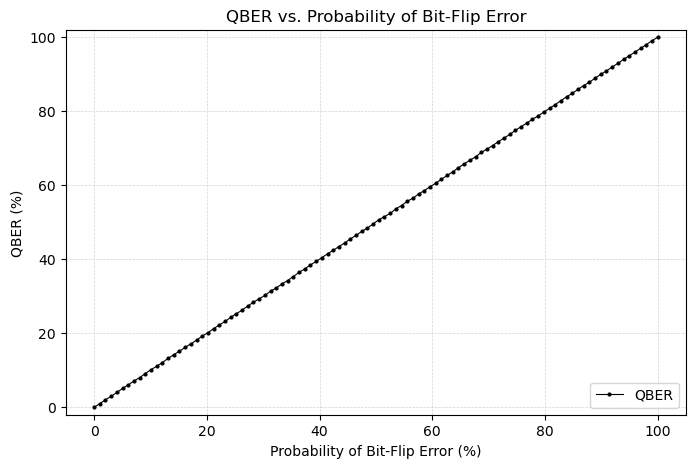

In [95]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(probs*100, qber_per_p_list, color='black', marker='o', markersize=2, linestyle='-', linewidth=0.8, label='QBER')
ax1.set_ylim(-2, 102)
ax1.set_xlabel('Probability of Bit-Flip Error (%)')
ax1.set_ylabel('QBER (%)', color='black')
ax1.tick_params('y', colors='black')
ax1.legend(loc='lower right')
plt.title("QBER vs. Probability of Bit-Flip Error")
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.savefig("qber_vs_bitflip.png", dpi=500, bbox_inches='tight')
plt.show()

**QBER vs. Phase-Flip Error (No Eavesdropping)**

In [96]:
num_bits = 1000
basis_options = ['X', 'Z']

num_simulations = 1000
probs = np.linspace(0, 1, num=100)
qber_per_p_list = []
for p in probs:
    qber_list = []
    for _ in range(num_simulations):
        qber, len_final_key=bb84(num_bits, basis_options, p_bit_flip = 0, p_phase_flip = p, p_depolarization = 0)
        qber_list.append(qber)
    qber_avg = (sum(qber_list))/(len(qber_list))
    qber_per_p_list.append(qber_avg)

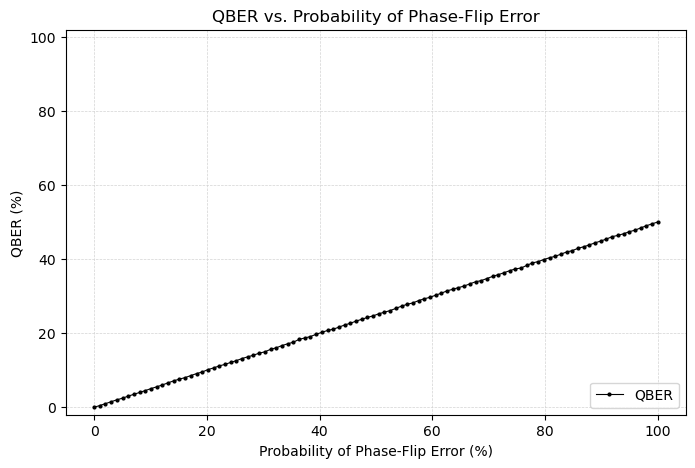

In [97]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(probs*100, qber_per_p_list, color='black', marker='o', markersize=2, linestyle='-', linewidth=0.8, label='QBER')
ax1.set_ylim(-2, 102)
ax1.set_xlabel('Probability of Phase-Flip Error (%)')
ax1.set_ylabel('QBER (%)', color='black')
ax1.tick_params('y', colors='black')
ax1.legend(loc='lower right')
plt.title("QBER vs. Probability of Phase-Flip Error")
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.savefig("qber_vs_phaseflip.png", dpi=500, bbox_inches='tight')
plt.show()

**QBER vs. Depolarization Error (No Eavesdropping)**

In [98]:
num_bits = 1000
basis_options = ['X', 'Z']

num_simulations = 1000
probs = np.linspace(0, 1, num=100)
qber_per_p_list = []
for p in probs:
    qber_list = []
    for _ in range(num_simulations):
        qber, len_final_key=bb84(num_bits, basis_options, p_bit_flip = 0, p_phase_flip = 0, p_depolarization = p)
        qber_list.append(qber)
    qber_avg = (sum(qber_list))/(len(qber_list))
    qber_per_p_list.append(qber_avg)

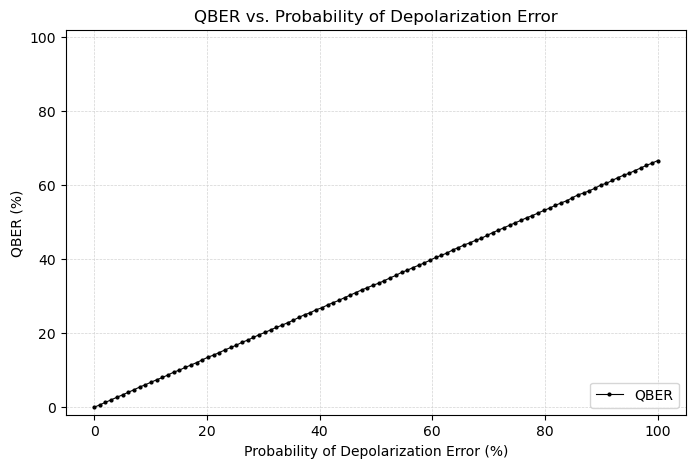

In [100]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(probs*100, qber_per_p_list, color='black', marker='o', markersize=2, linestyle='-', linewidth=0.8, label='QBER')
ax1.set_ylim(-2, 102)
ax1.set_xlabel('Probability of Depolarization Error (%)')
ax1.set_ylabel('QBER (%)', color='black')
ax1.tick_params('y', colors='black')
ax1.legend(loc='lower right')
plt.title("QBER vs. Probability of Depolarization Error")
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.savefig("qber_vs_depolarization.png", dpi=500, bbox_inches='tight')
plt.show()

**QBER vs. All Quantum Errors, No Eavesdropper**

In [101]:
num_bits = 1000
basis_options = ['X', 'Z']

num_simulations = 1000
probs = np.linspace(0, 1, num=100)
qber_per_p_list = []
for p in probs:
    qber_list = []
    for _ in range(num_simulations):
        qber, len_final_key=bb84(num_bits, basis_options, p_bit_flip = p, p_phase_flip = p, p_depolarization = p)
        qber_list.append(qber)
    qber_avg = (sum(qber_list))/(len(qber_list))
    qber_per_p_list.append(qber_avg)

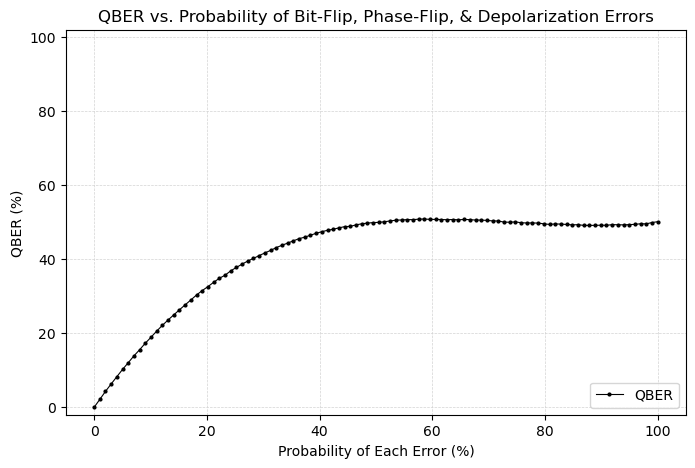

In [103]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(probs*100, qber_per_p_list, color='black', marker='o', markersize=2, linestyle='-', linewidth=0.8, label='QBER')
ax1.set_ylim(-2, 102)
ax1.set_xlabel('Probability of Each Error (%)')
ax1.set_ylabel('QBER (%)', color='black')
ax1.tick_params('y', colors='black')
ax1.legend(loc='lower right')
plt.title("QBER vs. Probability of Bit-Flip, Phase-Flip, & Depolarization Errors")
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.savefig("qber_vs_allerrors.png", dpi=500, bbox_inches='tight')
plt.show()

**QBER vs. Eavesdropper Presence, No Quantum Error**

In [65]:
num_bits_list = np.linspace(10,1000, num=100)
basis_options = ['X', 'Z']

num_simulations = 100
qber_per_num_bits = []
for num_bits in num_bits_list:
    qber_list = []
    for _ in range(num_simulations):
        num_bits = int(num_bits)
        qber, len_final_key=bb84(num_bits, basis_options, p_bit_flip = 0, p_phase_flip = 0, p_depolarization = 0)
        qber_list.append(qber)
    qber_avg = (sum(qber_list))/(len(qber_list))
    qber_per_num_bits.append(qber_avg)

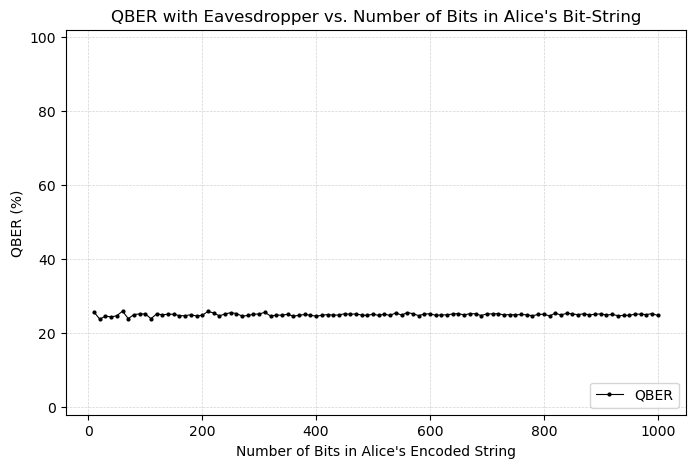

In [79]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(num_bits_list, qber_per_num_bits, color='black', marker='o', markersize=2, linestyle='-', linewidth=0.8, label='QBER')
ax1.set_ylim(-2, 102)
ax1.set_xlabel("Number of Bits in Alice's Encoded String")
ax1.set_ylabel('QBER (%)', color='black')
ax1.tick_params('y', colors='black')
ax1.legend(loc='lower right')
plt.title("QBER with Eavesdropper vs. Number of Bits in Alice's Bit-String")
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
#plt.savefig("qber_vs_eaves_noerror.png", dpi=500, bbox_inches='tight')
plt.show()

**QBER vs. All Quantum Errors, Presence of Eavesdropper**

In [58]:
num_bits = 1000
basis_options = ['X', 'Z']

num_simulations = 1000
probs = np.linspace(0, 1, num=100)
qber_per_p_list = []
for p in probs:
    qber_list = []
    for _ in range(num_simulations):
        qber, len_final_key=bb84(num_bits, basis_options, p_bit_flip = p, p_phase_flip = p, p_depolarization = p)
        qber_list.append(qber)
    qber_avg = (sum(qber_list))/(len(qber_list))
    qber_per_p_list.append(qber_avg)

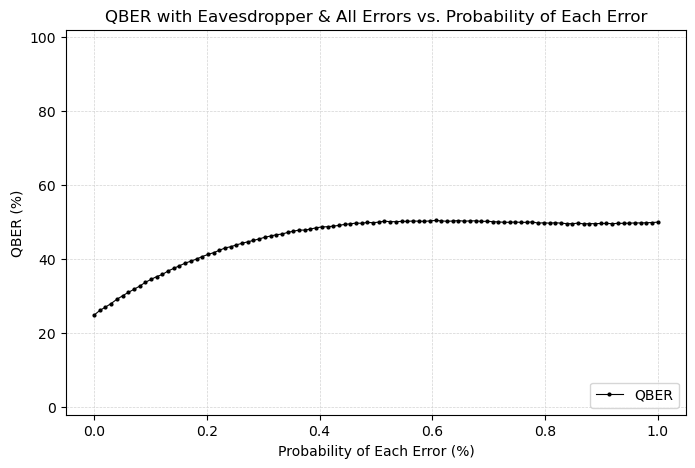

In [63]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(probs, qber_per_p_list, color='black', marker='o', markersize=2, linestyle='-', linewidth=0.8, label='QBER')
ax1.set_ylim(-2, 102)
ax1.set_xlabel("Probability of Each Error (%)")
ax1.set_ylabel('QBER (%)', color='black')
ax1.tick_params('y', colors='black')
ax1.legend(loc='lower right')
plt.title("QBER with Eavesdropper & All Errors vs. Probability of Each Error")
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
#plt.savefig("qber_vs_eaves_allerror.png", dpi=500, bbox_inches='tight')
plt.show()

**Length of Final Key vs. All Errors (After Sifting + Deleting Mismatched), No Eavesdropper**

In [110]:
num_bits = 1000
basis_options = ['X', 'Z']

num_simulations = 1000
probs = np.linspace(0, 1, num=100)
final_key_len_per_p = []
for p in probs:
    len_final_key_list = []
    for _ in range(num_simulations):
        qber, len_final_key=bb84(num_bits, basis_options, p_bit_flip = p, p_phase_flip = p, p_depolarization = p)
        len_final_key_list.append(len_final_key)
    len_avg = (sum(len_final_key_list))/(len(len_final_key_list))
    final_key_len_per_p.append(len_avg)

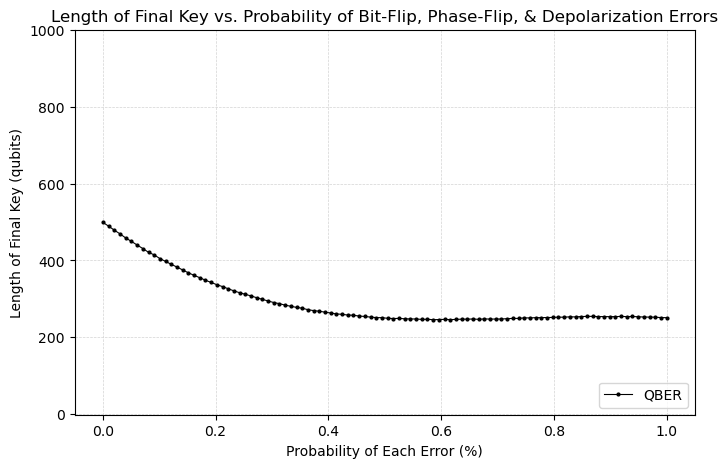

In [113]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(probs, final_key_len_per_p, color='black', marker='o', markersize=2, linestyle='-', linewidth=0.8, label='QBER')
ax1.set_ylim(-2, 1001)
ax1.set_xlabel("Probability of Each Error (%)")
ax1.set_ylabel('Length of Final Key (qubits)', color='black')
ax1.tick_params('y', colors='black')
ax1.legend(loc='lower right')
plt.title("Length of Final Key vs. Probability of Bit-Flip, Phase-Flip, & Depolarization Errors")
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
#plt.savefig("FinalKeyLen_vs_AllErrors.png", dpi=500, bbox_inches='tight')
plt.show()